In [53]:
import pandas as pd
import re
import os

# Set up the folder path where all the raw text files live
folder_path = r"C:\Users\USER\OneDrive\New folder"

# List of files we need to look for and process
files = [
    "Nigeria GDP",
    "annual revenue",
    "Annual inflation rate",
    "annual dept and money paid back",
    "annual oil price",
    "exchange rate",
    "annual reserve",
    "interest rate",
    "expenditure",
    "unemployment",
    "dept paid"
]

# This dictionary will hold our clean data before making it a table
data_dict = {}

for name in files:
    full_path = os.path.join(folder_path, name)
   
    # Skip the file if it's missing so the script doesn't crash
    if not os.path.exists(full_path):
        print(f"⚠️ File not found in folder: {name}")
        continue
       
    try:
        with open(full_path, 'r', encoding='utf-8') as f:
            # Read lines and strip out annoying empty spaces/blank lines
            lines = [line.strip() for line in f.readlines() if line.strip()]
           
            metric_name = "Unknown"
            temp = {}
           
            for line in lines:
                # Look for keywords to see if this line is a title/header
                if any(x in line for x in ["GDP", "Revenue", "Inflation", "Rate", "Price", "Population", "Debt", "Reserve", "Unemployment", "Expenditure"]):
                    metric_name = line.replace('"', '').strip()[:50]
                    continue
               
                # Regex magic: Look for a 4-digit year starting with 19 or 20, then grab the numbers after it
                match = re.search(r'\b(19\d{2}|20\d{2})\b.*?\b([\d.,]+)\b', line)
                if match:
                    year = int(match.group(1))
                    # Remove commas and spaces so python can read it as a pure number
                    value_str = match.group(2).replace(',', '').replace(' ', '').strip()
                    try:
                        temp[year] = float(value_str) if '.' in value_str else int(value_str)
                    except ValueError:
                        temp[year] = value_str  # Fallback to string if it's weird data
           
            # If we found data, save it to our main dictionary
            if temp:
                if metric_name == "Unknown":
                    metric_name = name
                data_dict[metric_name] = temp
                print(f"✅ Successfully loaded: {metric_name} ({len(temp)} rows)")
            else:
                print(f"❌ Failed to extract data patterns from: {name}")
               
    except Exception as e:
        print(f"❌ Error reading {name}: {e}")

# If we successfully collected data, smash it together into a spreadsheet
if data_dict:
    df = pd.DataFrame(data_dict)
    df = df.sort_index().reset_index()      # Sort years chronologically
    df.rename(columns={'index': 'Year'}, inplace=True)
   
    print("\nFINAL DATAFRAME PREVIEW:")
    print(df.head(15))
   
    # Define save paths for both CSV and Excel formats
    output_csv = os.path.join(folder_path, 'Nigeria_Economy_Clean_Data.csv')
    output_xlsx = os.path.join(folder_path, 'Nigeria_Economy_Clean_Data.xlsx')
   
    print(f"\n💾 Saved successfully to: {folder_path}")
else:
    print("\n❌ Extraction still failed...")

✅ Successfully loaded: Nominal GDP (Trillions NGN) (28 rows)
✅ Successfully loaded: Verified Gross Annual Revenue (Naira) (26 rows)
✅ Successfully loaded: Annual Inflation Rates (1999 - 2026) (28 rows)
✅ Successfully loaded: annual dept and money paid back (27 rows)
✅ Successfully loaded: annual oil price (27 rows)
✅ Successfully loaded: Annual Avg. Rate (₦/$) (28 rows)
✅ Successfully loaded: Reserves (USD) (28 rows)
✅ Successfully loaded: Central Bank Policy Rate (MPR/MRR)	Average Commerc (28 rows)
✅ Successfully loaded: expenditure (28 rows)
✅ Successfully loaded: unemployment (27 rows)
✅ Successfully loaded: dept paid (28 rows)

FINAL DATAFRAME PREVIEW:
    Year  Nominal GDP (Trillions NGN)  Verified Gross Annual Revenue (Naira)  \
0   1999                         4.00                                 949.19   
1   2000                         5.00                                   1.91   
2   2001                         5.00                                   2.23   
3   2002       

In [54]:
df1 =df

In [55]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 12 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Year                                                28 non-null     int64  
 1   Nominal GDP (Trillions NGN)                         28 non-null     float64
 2   Verified Gross Annual Revenue (Naira)               26 non-null     float64
 3   Annual Inflation Rates (1999 - 2026)                28 non-null     float64
 4   annual dept and money paid back                     27 non-null     float64
 5   annual oil price                                    27 non-null     float64
 6   Annual Avg. Rate (₦/$)                              28 non-null     float64
 7   Reserves (USD)                                      28 non-null     float64
 8   Central Bank Policy Rate (MPR/MRR)	Average Commerc  28 non-null     float64
 9   e

In [56]:
df1.dtypes

Year                                                     int64
Nominal GDP (Trillions NGN)                            float64
Verified Gross Annual Revenue (Naira)                  float64
Annual Inflation Rates (1999 - 2026)                   float64
annual dept and money paid back                        float64
annual oil price                                       float64
Annual Avg. Rate (₦/$)                                 float64
Reserves (USD)                                         float64
Central Bank Policy Rate (MPR/MRR)\tAverage Commerc    float64
expenditure                                            float64
unemployment                                           float64
dept paid                                              float64
dtype: object

In [57]:
df1.columns

Index(['Year', 'Nominal GDP (Trillions NGN)',
       'Verified Gross Annual Revenue (Naira)',
       'Annual Inflation Rates (1999 - 2026)',
       'annual dept and money paid back', 'annual oil price',
       'Annual Avg. Rate (₦/$)', 'Reserves (USD)',
       'Central Bank Policy Rate (MPR/MRR)\tAverage Commerc', 'expenditure',
       'unemployment', 'dept paid'],
      dtype='object')

MODIFYING COLUMN HADERS

In [58]:
df1.columns=["YEAR",
             "GDP(T₦)",
             "REVENUE(T₦)",
             "INFLATION_RATE(%)",
             "ANNUAL_DEBT",
             "OIL_PRICE(₦)",
             "EXCHANGE_RATE($/₦)",
             "ANNUAL_RESERVES(₦)",
             'INTEREST_RATE(%)',
             'EXPENDITURE',"UNEMPLOYMENT(%)",
             "DEBT_PAID(₦)"]

In [59]:
df1.head()

,YEAR,GDP(T₦),REVENUE(T₦),INFLATION_RATE(%),ANNUAL_DEBT,OIL_PRICE(₦),EXCHANGE_RATE($/₦),ANNUAL_RESERVES(₦),INTEREST_RATE(%),EXPENDITURE,UNEMPLOYMENT(%),DEBT_PAID(₦)
0,1999,4.00,949.19,6.62,3.55,17.40,93.95,4.99,18.00,0.30,3.82,1.72
1,2000,5.00,1.91,6.93,3.90,27.60,102.10,9.91,14.00,0.70,3.81,1.91
2,2001,5.00,2.23,18.87,4.41,23.10,111.93,10.44,20.50,0.89,3.81,2.13
3,2002,6.00,1.73,12.88,5.10,24.30,121.00,7.68,16.50,1.06,3.79,1.17
4,2003,7.00,2.58,14.04,5.72,28.10,129.30,7.47,15.00,1.45,3.77,1.81


####ADDING PRESIDENT COLUMN

In [60]:
import numpy as np

# 1. Set up the rules matching years to each administration
conditions = [
    (df1['YEAR'] >= 1999) & (df1['YEAR'] <= 2006), # Obasanjo
    (df1['YEAR'] >= 2007) & (df1['YEAR'] <= 2009), # Yar'Adua
    (df1['YEAR'] >= 2010) & (df1['YEAR'] <= 2014), # Jonathan
    (df1['YEAR'] >= 2015) & (df1['YEAR'] <= 2022), # Buhari
    (df1['YEAR'] >= 2023) & (df1['YEAR'] <= 2026)  # Tinubu
]

# 2. List out the names in the exact same order
presidents = [
    'Olusegun Obasanjo',
    'Umaru Yar\'Adua',
    'Goodluck Jonathan',
    'Muhammadu Buhari',
    'Bola Tinubu'
]

# 3. Create the new column instantly
df1['PRESIDENT'] = np.select(conditions, presidents, default='Unknown')

# 4. View the result to verify it worked
df1[['YEAR', 'PRESIDENT']].head(10)

,YEAR,PRESIDENT
0,1999,Olusegun Obasanjo
1,2000,Olusegun Obasanjo
2,2001,Olusegun Obasanjo
3,2002,Olusegun Obasanjo
4,2003,Olusegun Obasanjo
5,2004,Olusegun Obasanjo
6,2005,Olusegun Obasanjo
7,2006,Olusegun Obasanjo
8,2007,Umaru Yar'Adua
9,2008,Umaru Yar'Adua


In [61]:
df1.head()

,YEAR,GDP(T₦),REVENUE(T₦),INFLATION_RATE(%),ANNUAL_DEBT,OIL_PRICE(₦),EXCHANGE_RATE($/₦),ANNUAL_RESERVES(₦),INTEREST_RATE(%),EXPENDITURE,UNEMPLOYMENT(%),DEBT_PAID(₦),PRESIDENT
0,1999,4.00,949.19,6.62,3.55,17.40,93.95,4.99,18.00,0.30,3.82,1.72,Olusegun Obasanjo
1,2000,5.00,1.91,6.93,3.90,27.60,102.10,9.91,14.00,0.70,3.81,1.91,Olusegun Obasanjo
2,2001,5.00,2.23,18.87,4.41,23.10,111.93,10.44,20.50,0.89,3.81,2.13,Olusegun Obasanjo
3,2002,6.00,1.73,12.88,5.10,24.30,121.00,7.68,16.50,1.06,3.79,1.17,Olusegun Obasanjo
4,2003,7.00,2.58,14.04,5.72,28.10,129.30,7.47,15.00,1.45,3.77,1.81,Olusegun Obasanjo


####MOVING PRESIDENT COLUMN THE RIGHT FOR BETTER VISUALISATION

In [62]:
cols=list(df1.columns)

In [63]:
cols.insert(1,cols.pop(cols.index("PRESIDENT")))
df1 = df1[cols]           

In [64]:
df1.tail()

,YEAR,PRESIDENT,GDP(T₦),REVENUE(T₦),INFLATION_RATE(%),ANNUAL_DEBT,OIL_PRICE(₦),EXCHANGE_RATE($/₦),ANNUAL_RESERVES(₦),INTEREST_RATE(%),EXPENDITURE,UNEMPLOYMENT(%),DEBT_PAID(₦)
23,2022,Muhammadu Buhari,199.00,14.50,18.85,46.25,103.71,430.00,37.08,16.50,17.13,3.83,2.41
24,2023,Bola Tinubu,234.00,16.80,24.66,97.34,82.49,650.00,32.91,18.75,21.83,3.07,3.51
25,2024,Bola Tinubu,372.00,21.60,33.24,149.00,80.53,"1,200.00",40.88,27.25,28.78,3.05,4.66
26,2025,Bola Tinubu,441.00,NaN,21.00,159.28,71.91,"1,450.00",45.56,27.00,54.99,3.06,5.21
27,2026,Bola Tinubu,512.00,NaN,15.93,NaN,NaN,"1,300.00",50.81,26.50,58.18,NaN,5.45


In [65]:
df1.isnull().sum()

YEAR                  0
PRESIDENT             0
GDP(T₦)               0
REVENUE(T₦)           2
INFLATION_RATE(%)     0
ANNUAL_DEBT           1
OIL_PRICE(₦)          1
EXCHANGE_RATE($/₦)    0
ANNUAL_RESERVES(₦)    0
INTEREST_RATE(%)      0
EXPENDITURE           0
UNEMPLOYMENT(%)       1
DEBT_PAID(₦)          0
dtype: int64

In [66]:
df1.nunique()

YEAR                  28
PRESIDENT              5
GDP(T₦)               26
REVENUE(T₦)           26
INFLATION_RATE(%)     27
ANNUAL_DEBT           27
OIL_PRICE(₦)          27
EXCHANGE_RATE($/₦)    28
ANNUAL_RESERVES(₦)    27
INTEREST_RATE(%)      19
EXPENDITURE           27
UNEMPLOYMENT(%)       23
DEBT_PAID(₦)          28
dtype: int64

In [67]:
df1["GDP(T₦)"]

0      4.00
1      5.00
2      5.00
3      6.00
4      7.00
5      8.00
6     14.00
7     18.00
8     20.00
9     24.00
10    24.00
11    54.00
12    63.00
13    71.00
14    80.00
15    89.00
16    95.00
17   101.00
18   114.00
19   129.00
20   145.00
21   154.00
22   176.00
23   199.00
24   234.00
25   372.00
26   441.00
27   512.00
Name: GDP(T₦), dtype: float64

In [68]:
df1["DEBT_PAID(₦)"].max()

470.0

In [69]:
df1.columns

Index(['YEAR', 'PRESIDENT', 'GDP(T₦)', 'REVENUE(T₦)', 'INFLATION_RATE(%)',
       'ANNUAL_DEBT', 'OIL_PRICE(₦)', 'EXCHANGE_RATE($/₦)',
       'ANNUAL_RESERVES(₦)', 'INTEREST_RATE(%)', 'EXPENDITURE',
       'UNEMPLOYMENT(%)', 'DEBT_PAID(₦)'],
      dtype='object')

####CONVERTING SPECIFIC COLMNS FROM DOLAR TO NAIRA

In [70]:
df1["OIL_PRICE(₦)"]=df1['OIL_PRICE(₦)'].astype(float)

In [71]:
df1["OIL_PRICE(₦)"]=df1['OIL_PRICE(₦)']*df1['EXCHANGE_RATE($/₦)']
df1['DEBT_PAID(₦)']=df['DEBT_PAID(₦)'] *df1['EXCHANGE_RATE($/₦)']

In [72]:
pd.set_option("display.float_format",lambda x: f'{x:,.2f}')

In [73]:
#df1['OIL_PRICE(₦)'] =df1['OIL_PRICE(₦)'] .apply(lambda x: f'{x:,.2f}')

In [74]:
df1.head()

,YEAR,PRESIDENT,GDP(T₦),REVENUE(T₦),INFLATION_RATE(%),ANNUAL_DEBT,OIL_PRICE(₦),EXCHANGE_RATE($/₦),ANNUAL_RESERVES(₦),INTEREST_RATE(%),EXPENDITURE,UNEMPLOYMENT(%),DEBT_PAID(₦)
0,1999,Olusegun Obasanjo,4.00,949.19,6.62,3.55,"1,634.73",93.95,4.99,18.00,0.30,3.82,161.59
1,2000,Olusegun Obasanjo,5.00,1.91,6.93,3.90,"2,817.96",102.10,9.91,14.00,0.70,3.81,195.01
2,2001,Olusegun Obasanjo,5.00,2.23,18.87,4.41,"2,585.58",111.93,10.44,20.50,0.89,3.81,238.41
3,2002,Olusegun Obasanjo,6.00,1.73,12.88,5.10,"2,940.30",121.00,7.68,16.50,1.06,3.79,141.57
4,2003,Olusegun Obasanjo,7.00,2.58,14.04,5.72,"3,633.33",129.30,7.47,15.00,1.45,3.77,234.03


In [75]:
df1["REVENUE(T₦)"]

0    949.19
1      1.91
2      2.23
3      1.73
4      2.58
5      3.92
6      5.55
7      5.97
8      5.73
9      7.87
10     4.84
11     7.30
12    11.12
13    10.65
14     9.76
15    10.07
16     6.91
17     5.62
18     7.44
19     9.54
20    10.34
21     9.82
22    12.59
23    14.50
24    16.80
25    21.60
26      NaN
27      NaN
Name: REVENUE(T₦), dtype: float64

####MODIFIED SPECIFIC COLUMN BECUASE OF WRONG INPUT IN DATA

In [76]:
df1.loc[df["YEAR"] == 1999,'REVENUE(T₦)'] =0.95

In [77]:
df1["REVENUE(T₦)"]

0     0.95
1     1.91
2     2.23
3     1.73
4     2.58
5     3.92
6     5.55
7     5.97
8     5.73
9     7.87
10    4.84
11    7.30
12   11.12
13   10.65
14    9.76
15   10.07
16    6.91
17    5.62
18    7.44
19    9.54
20   10.34
21    9.82
22   12.59
23   14.50
24   16.80
25   21.60
26     NaN
27     NaN
Name: REVENUE(T₦), dtype: float64

In [78]:
df1.sort_values(by="GDP(T₦)",ascending=False).head(10)

,YEAR,PRESIDENT,GDP(T₦),REVENUE(T₦),INFLATION_RATE(%),ANNUAL_DEBT,OIL_PRICE(₦),EXCHANGE_RATE($/₦),ANNUAL_RESERVES(₦),INTEREST_RATE(%),EXPENDITURE,UNEMPLOYMENT(%),DEBT_PAID(₦)
27,2026,Bola Tinubu,512.00,NaN,15.93,NaN,NaN,"1,300.00",50.81,26.50,58.18,NaN,"7,085.00"
26,2025,Bola Tinubu,441.00,NaN,21.00,159.28,"104,269.50","1,450.00",45.56,27.00,54.99,3.06,"7,554.50"
25,2024,Bola Tinubu,372.00,21.60,33.24,149.00,"96,636.00","1,200.00",40.88,27.25,28.78,3.05,"5,592.00"
24,2023,Bola Tinubu,234.00,16.80,24.66,97.34,"53,618.50",650.00,32.91,18.75,21.83,3.07,"2,281.50"
23,2022,Muhammadu Buhari,199.00,14.50,18.85,46.25,"44,595.30",430.00,37.08,16.50,17.13,3.83,"1,036.30"
22,2021,Muhammadu Buhari,176.00,12.59,16.95,39.56,"29,012.02",410.47,40.52,11.50,13.59,5.45,866.09
21,2020,Muhammadu Buhari,154.00,9.82,11.40,32.92,"15,986.76",381.00,35.37,11.50,10.33,5.74,594.36
20,2019,Muhammadu Buhari,145.00,10.34,11.40,27.40,"19,736.88",306.95,38.59,13.50,8.92,5.21,411.31
19,2018,Muhammadu Buhari,129.00,9.54,12.09,24.39,"21,895.67",306.92,42.54,14.00,8.60,5.07,451.17
18,2017,Muhammadu Buhari,114.00,7.44,16.52,21.73,"16,617.32",306.31,38.77,14.00,7.40,4.83,"142,127.84"


In [79]:
df1.sort_values(by="DEBT_PAID(₦)",ascending=False).head(10)

,YEAR,PRESIDENT,GDP(T₦),REVENUE(T₦),INFLATION_RATE(%),ANNUAL_DEBT,OIL_PRICE(₦),EXCHANGE_RATE($/₦),ANNUAL_RESERVES(₦),INTEREST_RATE(%),EXPENDITURE,UNEMPLOYMENT(%),DEBT_PAID(₦)
18,2017,Muhammadu Buhari,114.00,7.44,16.52,21.73,"16,617.32",306.31,38.77,14.00,7.40,4.83,"142,127.84"
17,2016,Muhammadu Buhari,101.00,5.62,15.68,17.36,"13,328.96",305.22,26.99,14.00,6.06,4.50,"107,742.66"
16,2015,Muhammadu Buhari,95.00,6.91,9.01,12.60,"10,306.52",196.99,28.28,11.00,4.40,4.14,"65,203.69"
10,2009,Umaru Yar'Adua,24.00,4.84,12.54,3.82,"9,045.82",148.78,42.38,6.00,3.05,3.76,"63,677.84"
9,2008,Umaru Yar'Adua,24.00,7.87,11.58,2.92,"11,901.77",126.48,53.00,9.75,2.74,3.73,"59,445.60"
15,2014,Goodluck Jonathan,89.00,10.07,8.06,11.24,"16,793.23",169.68,34.24,13.00,4.96,3.90,"58,709.28"
12,2011,Goodluck Jonathan,63.00,11.12,10.84,6.62,"17,604.67",158.23,32.64,12.00,4.70,3.75,"55,538.73"
13,2012,Goodluck Jonathan,71.00,10.65,12.22,7.55,"17,561.63",157.32,43.83,12.00,4.90,3.73,"55,376.64"
11,2010,Goodluck Jonathan,54.00,7.30,13.72,5.22,"11,958.65",150.48,32.34,6.25,4.40,3.78,"53,269.92"
14,2013,Goodluck Jonathan,80.00,9.76,8.48,10.04,"17,073.23",157.27,42.85,12.00,4.99,3.71,"46,709.19"


In [80]:
df1.sort_values(by="ANNUAL_DEBT",ascending=False).head(10)

,YEAR,PRESIDENT,GDP(T₦),REVENUE(T₦),INFLATION_RATE(%),ANNUAL_DEBT,OIL_PRICE(₦),EXCHANGE_RATE($/₦),ANNUAL_RESERVES(₦),INTEREST_RATE(%),EXPENDITURE,UNEMPLOYMENT(%),DEBT_PAID(₦)
26,2025,Bola Tinubu,441.00,NaN,21.00,159.28,"104,269.50","1,450.00",45.56,27.00,54.99,3.06,"7,554.50"
25,2024,Bola Tinubu,372.00,21.60,33.24,149.00,"96,636.00","1,200.00",40.88,27.25,28.78,3.05,"5,592.00"
24,2023,Bola Tinubu,234.00,16.80,24.66,97.34,"53,618.50",650.00,32.91,18.75,21.83,3.07,"2,281.50"
23,2022,Muhammadu Buhari,199.00,14.50,18.85,46.25,"44,595.30",430.00,37.08,16.50,17.13,3.83,"1,036.30"
22,2021,Muhammadu Buhari,176.00,12.59,16.95,39.56,"29,012.02",410.47,40.52,11.50,13.59,5.45,866.09
21,2020,Muhammadu Buhari,154.00,9.82,11.40,32.92,"15,986.76",381.00,35.37,11.50,10.33,5.74,594.36
20,2019,Muhammadu Buhari,145.00,10.34,11.40,27.40,"19,736.88",306.95,38.59,13.50,8.92,5.21,411.31
19,2018,Muhammadu Buhari,129.00,9.54,12.09,24.39,"21,895.67",306.92,42.54,14.00,8.60,5.07,451.17
18,2017,Muhammadu Buhari,114.00,7.44,16.52,21.73,"16,617.32",306.31,38.77,14.00,7.40,4.83,"142,127.84"
17,2016,Muhammadu Buhari,101.00,5.62,15.68,17.36,"13,328.96",305.22,26.99,14.00,6.06,4.50,"107,742.66"


In [81]:
df1.groupby("PRESIDENT").mean(numeric_only=True)

,YEAR,GDP(T₦),REVENUE(T₦),INFLATION_RATE(%),ANNUAL_DEBT,OIL_PRICE(₦),EXCHANGE_RATE($/₦),ANNUAL_RESERVES(₦),INTEREST_RATE(%),EXPENDITURE,UNEMPLOYMENT(%),DEBT_PAID(₦)
PRESIDENT,,,,,,,,,,,,
Bola Tinubu,"2,024.50",389.75,19.20,23.71,135.21,"84,841.33","1,150.00",42.54,24.88,40.95,3.06,"5,628.25"
Goodluck Jonathan,"2,012.00",71.40,9.78,10.66,8.13,"16,198.28",158.60,37.18,11.05,4.79,3.77,"53,920.75"
Muhammadu Buhari,"2,018.50",139.12,9.60,13.99,27.78,"21,434.93",330.48,36.02,13.25,9.55,4.85,"39,804.18"
Olusegun Obasanjo,"2,002.50",8.38,3.10,12.55,4.19,"4,116.36",118.90,16.00,15.25,1.13,3.77,483.10
Umaru Yar'Adua,"2,008.00",22.67,6.15,9.83,3.12,"9,701.36",131.16,48.90,8.42,2.73,3.73,"41,081.73"


In [83]:
import os

if os.path.exists("nigeria_macro_clean.csv"):
    os.remove("nigeria_macro_clean.csv")
    print("Old file deleted.")

df1.to_csv("nigeria_macro_clean.csv", index=False)
print("Re-exported.Columns now:",list(df1.columns))

Old file deleted.
Re-exported.Columns now: ['YEAR', 'PRESIDENT', 'GDP(T₦)', 'REVENUE(T₦)', 'INFLATION_RATE(%)', 'ANNUAL_DEBT', 'OIL_PRICE(₦)', 'EXCHANGE_RATE($/₦)', 'ANNUAL_RESERVES(₦)', 'INTEREST_RATE(%)', 'EXPENDITURE', 'UNEMPLOYMENT(%)', 'DEBT_PAID(₦)']


#### CHART AND VISUALISATION

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

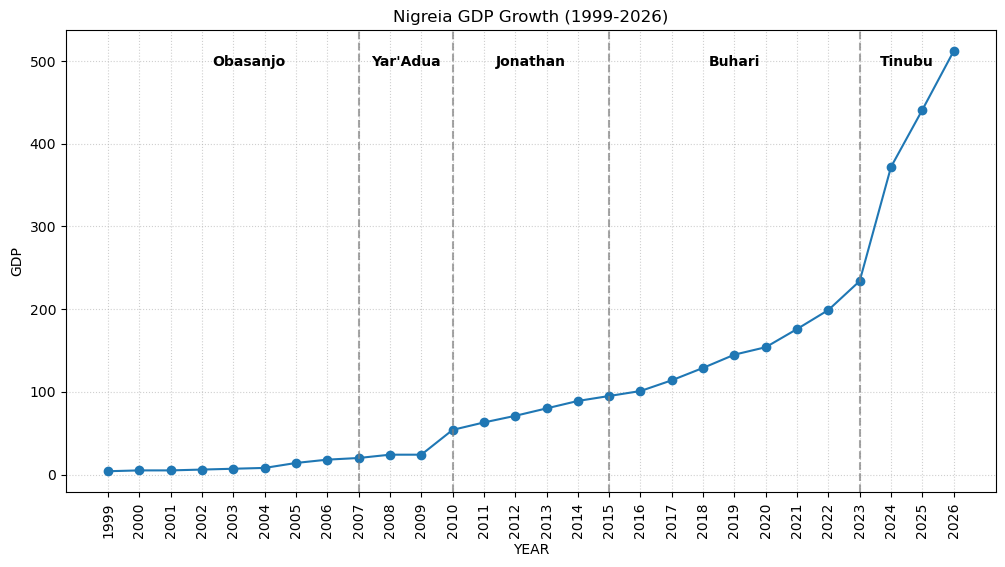

<function matplotlib.pyplot.show(close=None, block=None)>

In [33]:
plt.figure(figsize=(12,6))

plt.plot(df1["YEAR"],df1["GDP(T₦)"],marker="o")

plt.title("Nigreia GDP Growth (1999-2026)")
plt.xlabel("YEAR")
plt.ylabel("GDP")
plt.grid()

import matplotlib.pyplot as plt

plt.axvline(x=2007, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2010, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2015, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2023, linestyle='--', color='gray', alpha=0.7)

y_pos = plt.ylim()[1] * 0.92

plt.text(2003.5, y_pos, 'Obasanjo', ha='center', fontweight='bold')
plt.text(2008.5, y_pos, "Yar'Adua", ha='center', fontweight='bold')
plt.text(2012.5, y_pos, 'Jonathan', ha='center', fontweight='bold')
plt.text(2019.0, y_pos, 'Buhari', ha='center', fontweight='bold')
plt.text(2024.5, y_pos, 'Tinubu', ha='center', fontweight='bold')

plt.xticks(df1['YEAR'], rotation=90)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()
plt.show


Commentary
Nigeria's economy expanded considerably over the last two decades, especially during the early 2000s when rising oil prices and economic reforms supported growth. However, the trend was interrupted in 2016 when the collapse in global oil prices pushed the country into recession. Another slowdown occurred in 2020 due to the COVID-19 pandemic.
These episodes reveal how vulnerable economic growth remains to external shocks. Although GDP has generally increased, growth alone has not automatically translated into economic stability or improved living standards.
Possible Policy Direction: Reduce dependence on crude oil by promoting agriculture, manufacturing, and technology-driven industries.

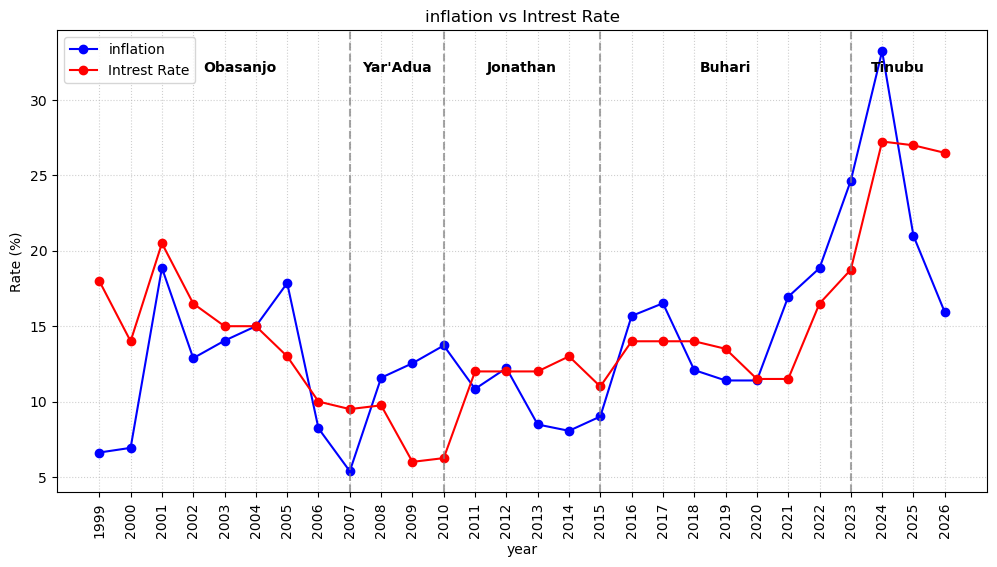

In [34]:
plt.figure(figsize=(12,6))

plt.plot(df1["YEAR"],
df1["INFLATION_RATE(%)"],
        marker="o",
        label="inflation",color='blue')
plt.plot(df1["YEAR"],
df1["INTEREST_RATE(%)"],
              marker="o",
            label="Intrest Rate",color='red')
plt.title("inflation vs Intrest Rate")
plt.xlabel ("year")
plt.ylabel("Rate (%)")
plt.grid(True)
plt.legend()

import matplotlib.pyplot as plt

plt.axvline(x=2007, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2010, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2015, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2023, linestyle='--', color='gray', alpha=0.7)

y_pos = plt.ylim()[1] * 0.92

plt.text(2003.5, y_pos, 'Obasanjo', ha='center', fontweight='bold')
plt.text(2008.5, y_pos, "Yar'Adua", ha='center', fontweight='bold')
plt.text(2012.5, y_pos, 'Jonathan', ha='center', fontweight='bold')
plt.text(2019.0, y_pos, 'Buhari', ha='center', fontweight='bold')
plt.text(2024.5, y_pos, 'Tinubu', ha='center', fontweight='bold')

plt.xticks(df1['YEAR'], rotation=90)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()           
 

Commentary
Several periods of high inflation can be observed, particularly around 2016 and between 2023 and 2025. During these periods, interest rates were increased in an attempt to contain inflation, yet prices continued to rise.
The 2016 spike was largely driven by foreign exchange shortages and falling oil revenues, while the recent inflation surge followed subsidy removal, exchange-rate reforms, and rising food prices.
This suggests that Nigeria's inflation problem is not purely monetary but also structural.
Possible Policy Direction: Improve food supply chains, increase agricultural productivity, and stabilize the foreign exchange market rather than relying solely on interest-rate adjustments.

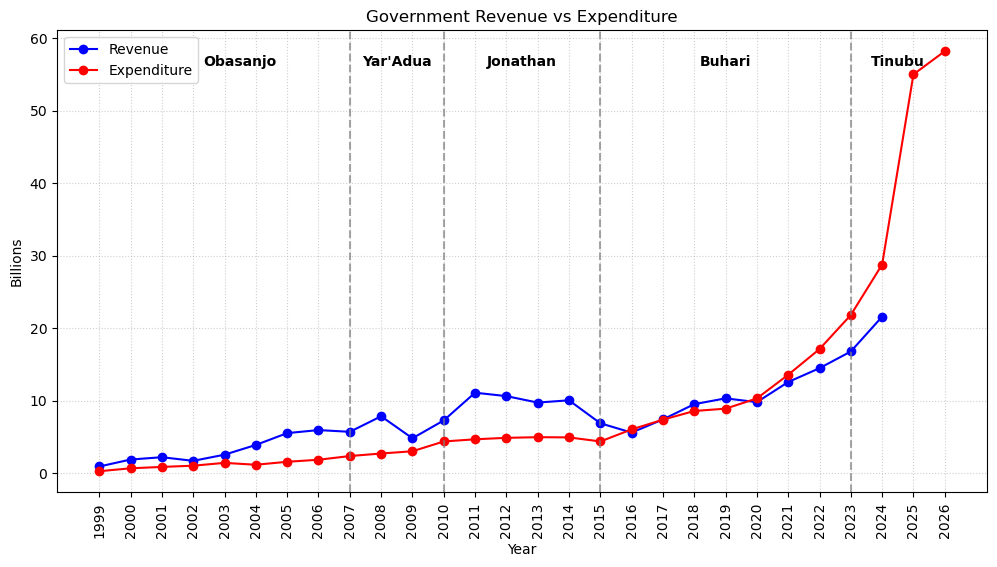

In [35]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))


plt.plot(df1['YEAR'], df1['REVENUE(T₦)'],
         marker='o',
         label='Revenue',color='blue')


plt.plot(df1['YEAR'], df1['EXPENDITURE'],
         marker='o',
         label='Expenditure',color='red')


plt.title('Government Revenue vs Expenditure')
plt.xlabel('Year')
plt.ylabel('Billions')
plt.legend()
plt.grid()
import matplotlib.pyplot as plt

plt.axvline(x=2007, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2010, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2015, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2023, linestyle='--', color='gray', alpha=0.7)

y_pos = plt.ylim()[1] * 0.92

plt.text(2003.5, y_pos, 'Obasanjo', ha='center', fontweight='bold')
plt.text(2008.5, y_pos, "Yar'Adua", ha='center', fontweight='bold')
plt.text(2012.5, y_pos, 'Jonathan', ha='center', fontweight='bold')
plt.text(2019.0, y_pos, 'Buhari', ha='center', fontweight='bold')
plt.text(2024.5, y_pos, 'Tinubu', ha='center', fontweight='bold')

plt.xticks(df1['YEAR'], rotation=90)
plt.grid(True, linestyle=':', alpha=0.6)


# Display the chart
plt.show()

Government expenditure has consistently grown faster than revenue, with the gap becoming more pronounced after 2015. Falling oil revenues, increased security spending, and the impact of the COVID-19 pandemic contributed to this widening imbalance.
Persistent deficits have forced the government to rely increasingly on borrowing to finance spending.
Possible Policy Direction: Strengthen non-oil revenue sources, improve tax collection, and ensure that public spending is directed toward productive sectors.

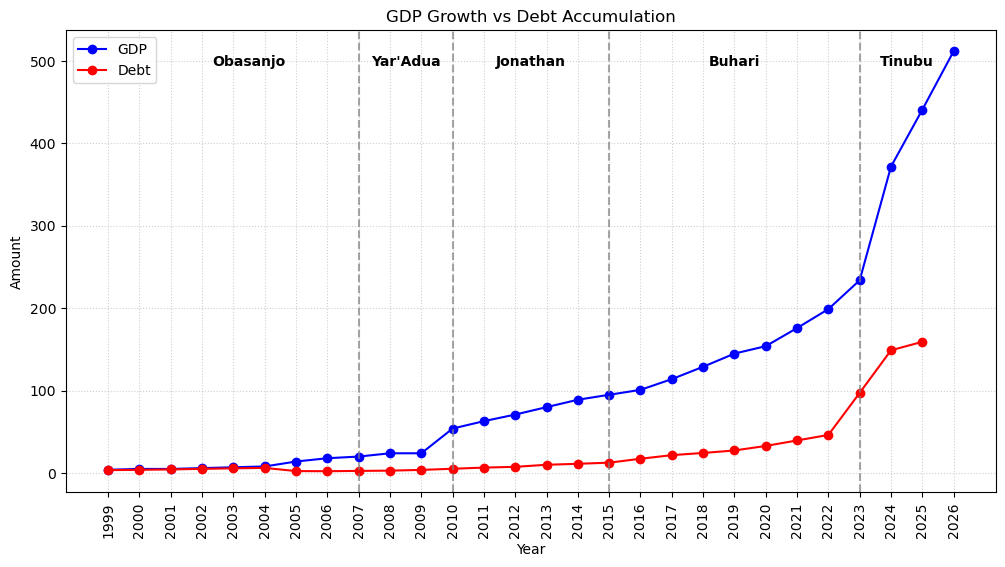

In [36]:
plt.figure(figsize=(12, 6))

plt.plot(df1['YEAR'], df1['GDP(T₦)'], marker='o', label='GDP',color='blue')

plt.plot(df1['YEAR'], df1['ANNUAL_DEBT'], marker='o', label='Debt', color='red')

plt.title('GDP Growth vs Debt Accumulation')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend()
plt.grid()
import matplotlib.pyplot as plt

plt.axvline(x=2007, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2010, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2015, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2023, linestyle='--', color='gray', alpha=0.7)

y_pos = plt.ylim()[1] * 0.92

plt.text(2003.5, y_pos, 'Obasanjo', ha='center', fontweight='bold')
plt.text(2008.5, y_pos, "Yar'Adua", ha='center', fontweight='bold')
plt.text(2012.5, y_pos, 'Jonathan', ha='center', fontweight='bold')
plt.text(2019.0, y_pos, 'Buhari', ha='center', fontweight='bold')
plt.text(2024.5, y_pos, 'Tinubu', ha='center', fontweight='bold')

plt.xticks(df1['YEAR'], rotation=90)
plt.grid(True, linestyle=':', alpha=0.6)


plt.show()

Commentary
While Nigeria's economy expanded over the study period, public debt increased at an even faster pace, particularly after 2015 and during the COVID-19 crisis in 2020.
The sharp increase in borrowing reflects the government's attempt to support the economy during periods of weak revenue and economic stress.
The concern is not necessarily the existence of debt, but whether borrowed funds are generating sufficient economic returns.
Possible Policy Direction: Ensure that future borrowing is tied to productive investments capable of generating growth and increasing government revenue.

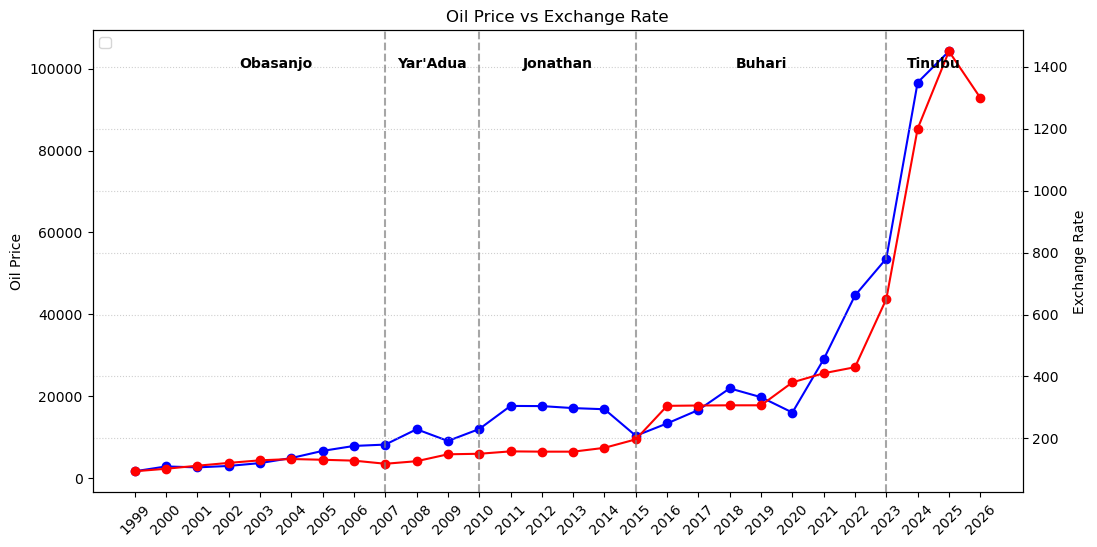

In [37]:
plt.close ("all")

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(df1['YEAR'],
         df1['OIL_PRICE(₦)'],marker="o",
         color='blue')

ax1.set_ylabel('Oil Price')
ax1.tick_params(axis='x',labelrotation=45)
ax2 = ax1.twinx()

ax2.plot(df1['YEAR'],
         df1['EXCHANGE_RATE($/₦)'],marker="o",
         color='red')

ax2.set_ylabel('Exchange Rate')

plt.title('Oil Price vs Exchange Rate')

plt.grid(True)


import matplotlib.pyplot as plt

plt.axvline(x=2007, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2010, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2015, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2023, linestyle='--', color='gray', alpha=0.7)

y_pos = plt.ylim()[1] * 0.92

plt.text(2003.5, y_pos, 'Obasanjo', ha='center', fontweight='bold')
plt.text(2008.5, y_pos, "Yar'Adua", ha='center', fontweight='bold')
plt.text(2012.5, y_pos, 'Jonathan', ha='center', fontweight='bold')
plt.text(2019.0, y_pos, 'Buhari', ha='center', fontweight='bold')
plt.text(2024.5, y_pos, 'Tinubu', ha='center', fontweight='bold')

plt.xticks(df1['YEAR'], rotation=90)
plt.grid(True, linestyle=':', alpha=0.6)

lines1,labels1,=ax1.get_legend_handles_labels()
lines2,labels2,=ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2,labels1+labels2, loc='upper left')
plt.show()

Commentary
The chart clearly highlights Nigeria's dependence on crude oil. Major oil price declines in 2008, 2014–2016, and 2020 were followed by significant depreciation of the naira.
Lower oil prices reduced foreign exchange earnings, making it increasingly difficult to support the domestic currency.
This relationship demonstrates the extent to which external shocks continue to influence exchange-rate stability.
Possible Policy Direction: Diversify export earnings and reduce reliance on oil as the country's primary source of foreign exchange.

In [38]:
df1.columns

Index(['YEAR', 'PRESIDENT', 'GDP(T₦)', 'REVENUE(T₦)', 'INFLATION_RATE(%)',
       'ANNUAL_DEBT', 'OIL_PRICE(₦)', 'EXCHANGE_RATE($/₦)',
       'ANNUAL_RESERVES(₦)', 'INTEREST_RATE(%)', 'EXPENDITURE',
       'UNEMPLOYMENT(%)', 'DEBT_PAID(₦)'],
      dtype='object')

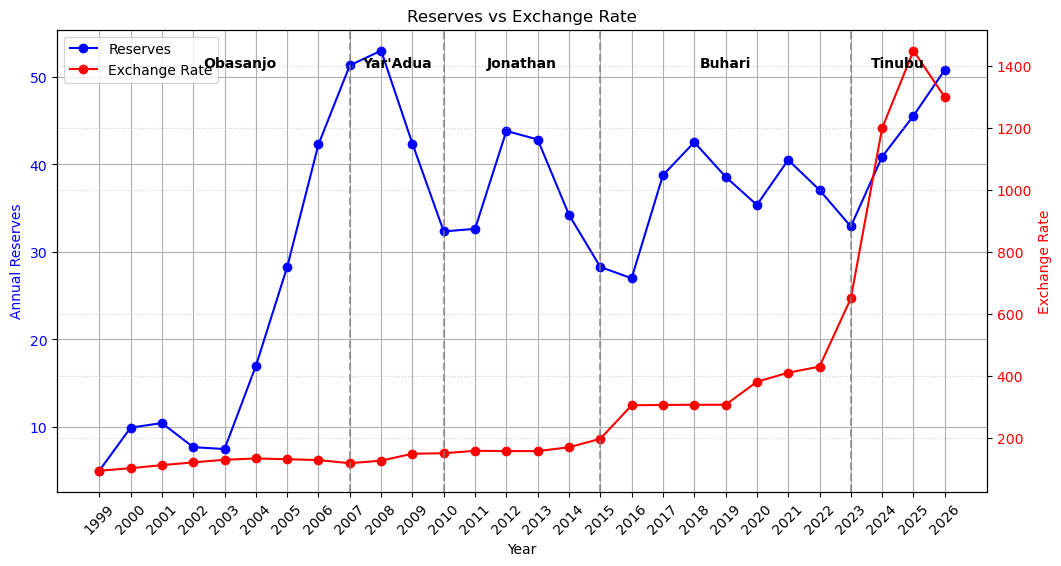

In [39]:
plt.close("all")

fig, ax1 = plt.subplots(figsize=(12, 6))


ax1.plot(df1['YEAR'], df1['ANNUAL_RESERVES(₦)'], color='blue', marker='o', label='Reserves')
ax1.set_xlabel('Year')
ax1.set_ylabel('Annual Reserves', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.tick_params(axis='x',labelrotation=45)

ax2 = ax1.twinx()
ax2.plot(df1['YEAR'], df1['EXCHANGE_RATE($/₦)'], color='red', marker='o', label='Exchange Rate')
ax2.set_ylabel('Exchange Rate', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Reserves vs Exchange Rate')
plt.xticks(rotation=45)
ax1.grid(True)


import matplotlib.pyplot as plt

plt.axvline(x=2007, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2010, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2015, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2023, linestyle='--', color='gray', alpha=0.7)

y_pos = plt.ylim()[1] * 0.92

plt.text(2003.5, y_pos, 'Obasanjo', ha='center', fontweight='bold')
plt.text(2008.5, y_pos, "Yar'Adua", ha='center', fontweight='bold')
plt.text(2012.5, y_pos, 'Jonathan', ha='center', fontweight='bold')
plt.text(2019.0, y_pos, 'Buhari', ha='center', fontweight='bold')
plt.text(2024.5, y_pos, 'Tinubu', ha='center', fontweight='bold')

plt.xticks(df1['YEAR'], rotation=90)
plt.grid(True, linestyle=':', alpha=0.6)

lines1,labels1,=ax1.get_legend_handles_labels()
lines2,labels2,=ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2,labels1+labels2, loc='upper left')

plt.show()

Commentary
Periods of declining foreign reserves often coincided with increased pressure on the exchange rate. When reserves weaken, the country's ability to defend the naira becomes limited, leading to higher exchange-rate volatility.
This pattern became particularly visible during periods of declining oil revenues and external shocks.
Possible Policy Direction: Build stronger reserve buffers during periods of high oil prices and encourage greater inflows from non-oil exports and foreign investment.

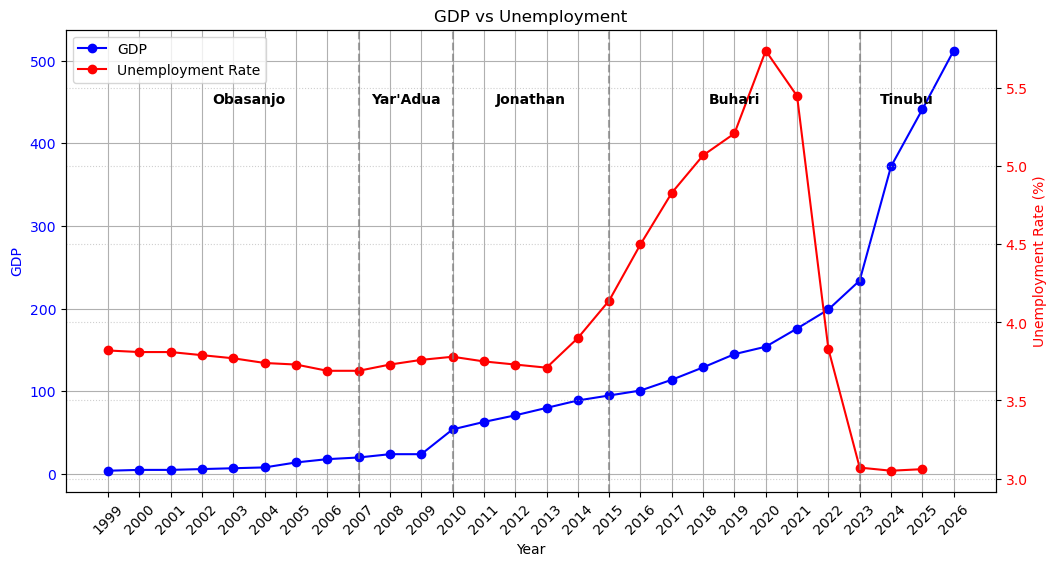

In [40]:
plt.close("all")
fig, ax1 = plt.subplots(figsize=(12, 6))


ax1.plot(df1['YEAR'], df1['GDP(T₦)'], color='blue', marker='o', label='GDP')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.tick_params(axis='x',labelrotation=45)

ax2 = ax1.twinx()
ax2.plot(df1['YEAR'], df1['UNEMPLOYMENT(%)'], color='red', marker='o', label='Unemployment Rate')
ax2.set_ylabel('Unemployment Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('GDP vs Unemployment')
ax1.grid(True)
import matplotlib.pyplot as plt

plt.axvline(x=2007, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2010, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2015, linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=2023, linestyle='--', color='gray', alpha=0.7)

y_pos = plt.ylim()[1] * 0.92

plt.text(2003.5, y_pos, 'Obasanjo', ha='center', fontweight='bold')
plt.text(2008.5, y_pos, "Yar'Adua", ha='center', fontweight='bold')
plt.text(2012.5, y_pos, 'Jonathan', ha='center', fontweight='bold')
plt.text(2019.0, y_pos, 'Buhari', ha='center', fontweight='bold')
plt.text(2024.5, y_pos, 'Tinubu', ha='center', fontweight='bold')

plt.xticks(df1['YEAR'], rotation=90)
plt.grid(True, linestyle=':', alpha=0.6)

lines1,labels1,=ax1.get_legend_handles_labels()
lines2,labels2,=ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2,labels1+labels2, loc='upper left')


plt.show()

Commentary
Despite long-term growth in economic output, unemployment remained persistently high and worsened significantly after 2015.
This suggests that economic growth has not translated into enough employment opportunities for the growing population. In other words, Nigeria has experienced periods of what economists describe as "jobless growth."
Possible Policy Direction: Encourage sectors with strong employment potential, such as manufacturing, agriculture, and small and medium-sized enterprises.

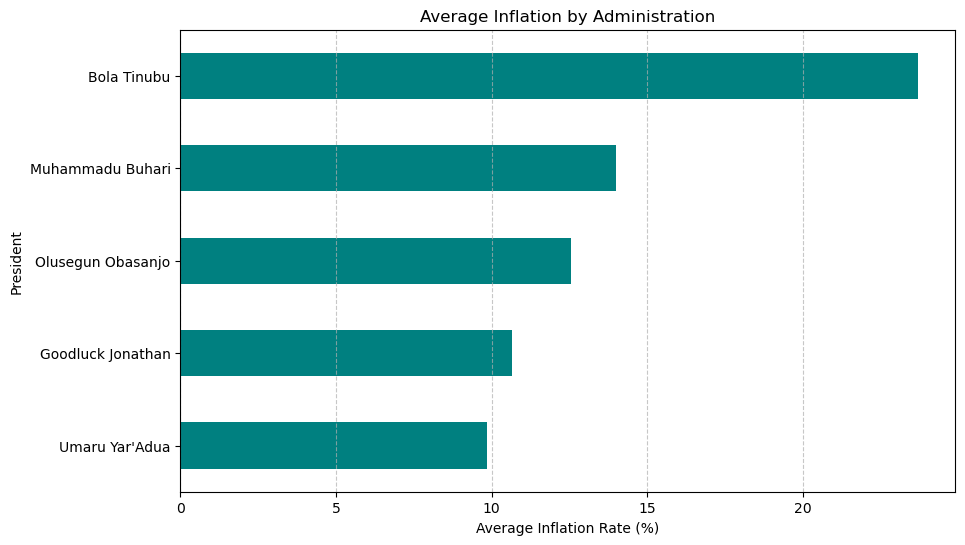

In [41]:
avg_inf = df1.groupby('PRESIDENT')['INFLATION_RATE(%)'].mean().sort_values()

plt.figure(figsize=(10, 6))

avg_inf.plot(kind='barh', color='teal')

plt.title('Average Inflation by Administration')
plt.xlabel('Average Inflation Rate (%)')
plt.ylabel('President')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

Commentary
Differences in average inflation across administrations should be interpreted carefully. Each government operated under different economic circumstances and faced unique challenges.
For example, the Buhari administration experienced the 2016 recession and the COVID-19 pandemic, while the Tinubu administration inherited existing inflationary pressures and implemented major reforms that initially contributed to higher prices.
Therefore, inflation outcomes cannot be explained solely by policy decisions, as external shocks also played an important role.
Possible Policy Direction: Strengthen institutions and implement long-term policies that improve resilience to external shocks.

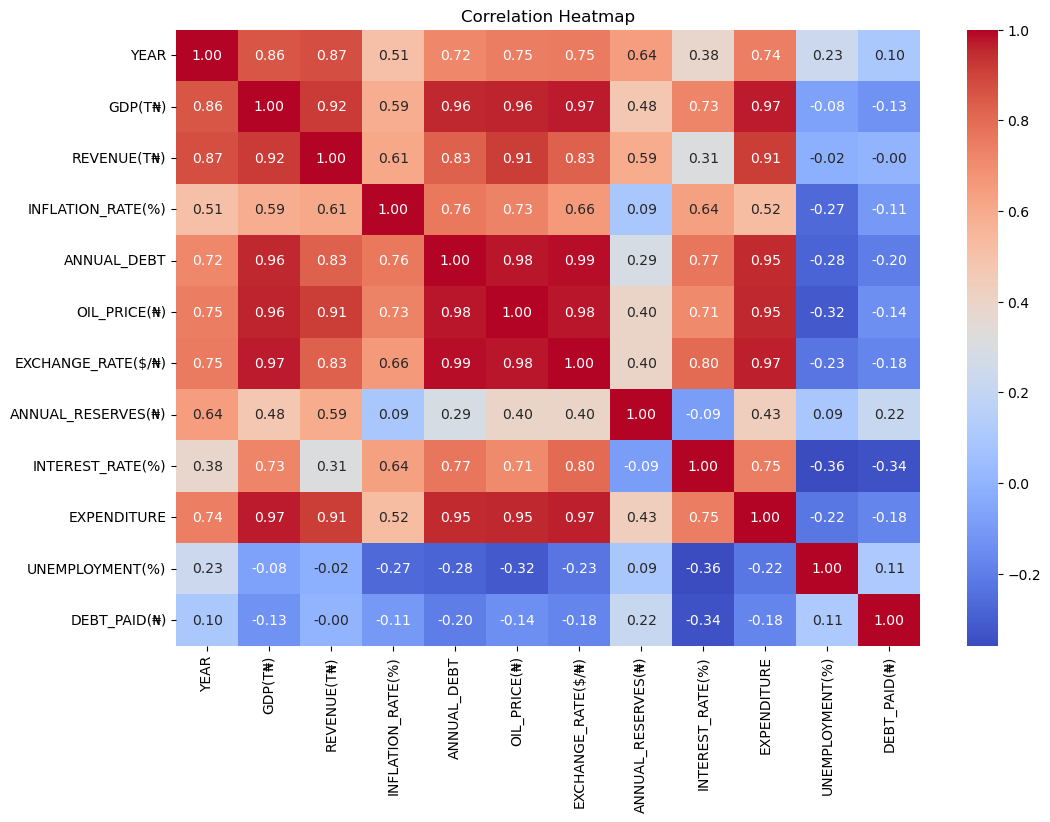

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.heatmap(df1.drop(columns=['PRESIDENT']).corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

Commentary
The heatmap provides a broad overview of how macroeconomic variables move together. Some indicators show strong relationships, while others appear less connected.
For example, debt and GDP tend to rise together, while exchange-rate movements appear closely linked to inflation and external factors.
However, correlation should not be confused with causation. These relationships only indicate patterns in the data and do not necessarily imply that one variable directly causes changes in another.
Possible Next Step: Apply regression analysis and other statistical techniques to investigate the underlying drivers of these relationships.